In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate
from sklearn.metrics import r2_score, mean_squared_error
from math import sqrt

In [4]:
# === file pathsn ===

original_path = "/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/original-data-splits"
filtered_path = "/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/reduced_features_1"
reu_path = "/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/reduced_features_reu_2"
meta_cols = ['molecule_chembl_id', 'canonical_smiles', 'activity_class', 'pIC50']

In [5]:
targets = ["5-HT6","ache", "bace1", "buche","esr1","gsk-3beta", "mao-b"]

results = []


In [6]:

def evaluate_model(df_train, df_test, version, target):
    X_train = df_train.drop(columns=meta_cols)
    y_train = df_train["pIC50"]
    X_test = df_test.drop(columns=meta_cols)
    y_test = df_test["pIC50"]

    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    cv = cross_validate(rf, X_train, y_train, cv=5,
                        scoring=["r2", "neg_mean_squared_error"], n_jobs=-1)

    val_r2 = np.mean(cv["test_r2"])
    val_rmse = sqrt(-np.mean(cv["test_neg_mean_squared_error"]))

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Target": target,
        "Version": version,
        "Train Samples": len(X_train),
        "Val R²": round(val_r2, 4),
        "Val RMSE": round(val_rmse, 4),
        "Test R²": round(test_r2, 4),
        "Test RMSE": round(test_rmse, 4)
    })




In [7]:
# === Evaluation Loop ===
for target in targets:
    print(f"\n Processing Target: {target.upper()}")

    try:
        # Load and evaluate original
        df_train = pd.read_csv(f"{original_path}/{target}_original_split_train.csv").dropna(how="any")
        df_test = pd.read_csv(f"{original_path}/{target}_original_split_test.csv").dropna(how="any")
        evaluate_model(df_train, df_test, "Original", target)
    except FileNotFoundError as e:
        print(f" Missing original files for {target}: {e}")
        continue

    try:
        # Load and evaluate filtered
        df_train = pd.read_csv(f"{filtered_path}/{target}_feature_filtered_1_train.csv").dropna(how="any")
        df_test = pd.read_csv(f"{filtered_path}/{target}_feature_filtered_1_test.csv").dropna(how="any")
        evaluate_model(df_train, df_test, "Filtered", target)
    except FileNotFoundError as e:
        print(f" Missing filtered files for {target}: {e}")

    try:
        # Load and evaluate RFECV
        df_train = pd.read_csv(f"{reu_path}/{target}_train_reu.csv").dropna(how="any")
        df_test = pd.read_csv(f"{reu_path}/{target}_test_reu.csv").dropna(how="any")
        evaluate_model(df_train, df_test, "RFECV", target)
    except FileNotFoundError as e:
        print(f" Missing REU files for {target}: {e}")



 Processing Target: 5-HT6

 Processing Target: ACHE

 Processing Target: BACE1

 Processing Target: BUCHE

 Processing Target: ESR1

 Processing Target: GSK-3BETA

 Processing Target: MAO-B


In [8]:

# === Final Output ===
results_df = pd.DataFrame(results)
display(results_df.sort_values(by=["Target", "Version"]))

,Target,Version,Train Samples,Val R²,Val RMSE,Test R²,Test RMSE
1,5-HT6,Filtered,752,0.5356,0.7257,0.5467,0.6731
0,5-HT6,Original,752,0.5326,0.7276,0.5316,0.6842
2,5-HT6,RFECV,752,0.5346,0.7260,0.5443,0.6748
4,ache,Filtered,5274,0.6589,0.7485,0.6580,0.7605
3,ache,Original,5274,0.6572,0.7504,0.6587,0.7597
5,ache,RFECV,5274,0.6596,0.7477,0.6588,0.7596
7,bace1,Filtered,7833,0.6240,0.7440,0.6363,0.7210
6,bace1,Original,7833,0.6230,0.7450,0.6343,0.7230
8,bace1,RFECV,7833,0.6234,0.7447,0.6348,0.7225
10,buche,Filtered,3107,0.7363,0.6485,0.7319,0.6490


In [9]:
# === Save results ===
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M")

results_out = "/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/reduced_features_reu_2/rf_performance_comparison_{timestamp}.csv"
results_df.to_csv(results_out, index=False)

print(f"\n Results saved to: {results_out}")



 Results saved to: /content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/reduced_features_reu_2/rf_performance_comparison_{timestamp}.csv


# **Barplot for Test R² Comparison**

/tmp/ipython-input-2091349124.py:7: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(data=results_df, x="Target", y="Test R²", hue="Version", palette=palette)


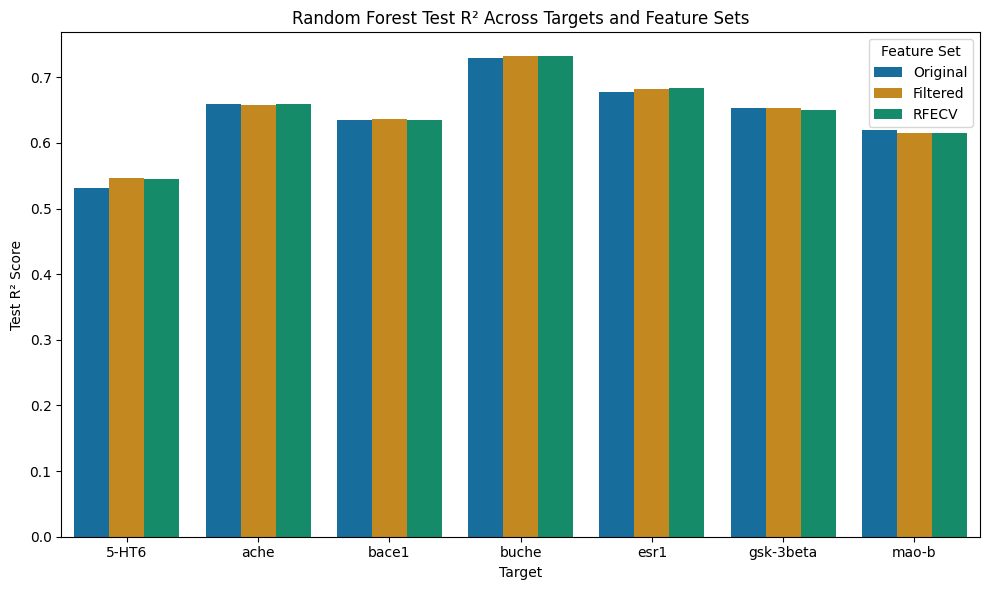

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = sns.color_palette("colorblind")

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Target", y="Test R²", hue="Version", palette=palette)
plt.title("Random Forest Test R² Across Targets and Feature Sets")
plt.ylabel("Test R² Score")
plt.xlabel("Target")
plt.legend(title="Feature Set")
plt.tight_layout()

# Save plot
plt.savefig("/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/reduced_features_reu_2/test_r2_comparison.png", dpi=300)
plt.show()


# **Barplot for Test RMSE Comparison**

/tmp/ipython-input-2324208897.py:2: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(data=results_df, x="Target", y="Test RMSE", hue="Version", palette=palette)


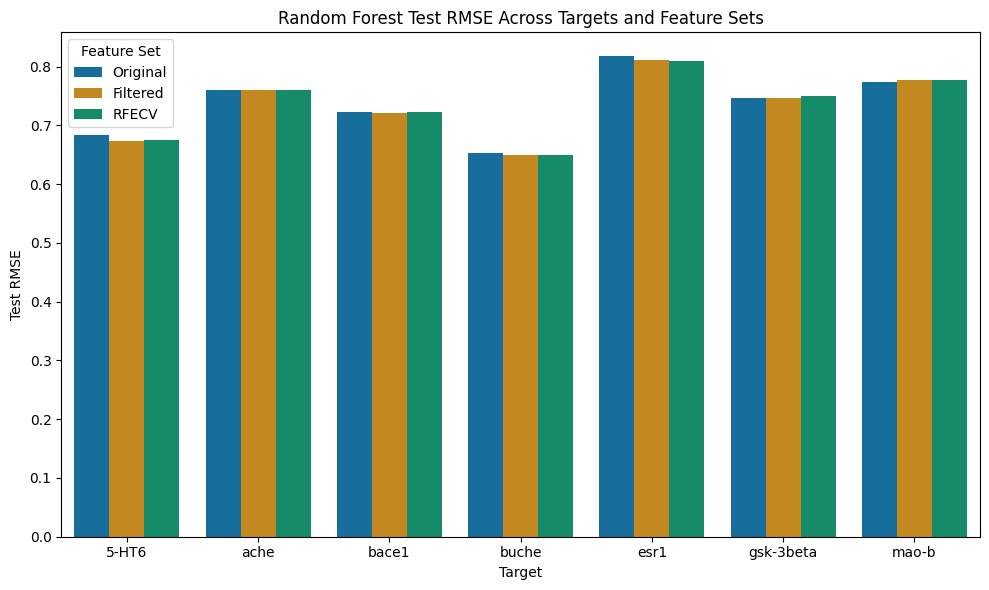

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Target", y="Test RMSE", hue="Version", palette=palette)
plt.title("Random Forest Test RMSE Across Targets and Feature Sets")
plt.ylabel("Test RMSE")
plt.xlabel("Target")
plt.legend(title="Feature Set")
plt.tight_layout()

# Save plot
plt.savefig("/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/reduced_features_reu_2/test_rmse_comparison.png", dpi=300)
plt.show()


# **Lineplot for trends**

/tmp/ipython-input-204264012.py:2: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.lineplot(data=results_df, x="Target", y="Test R²", hue="Version", marker='o', palette=palette)


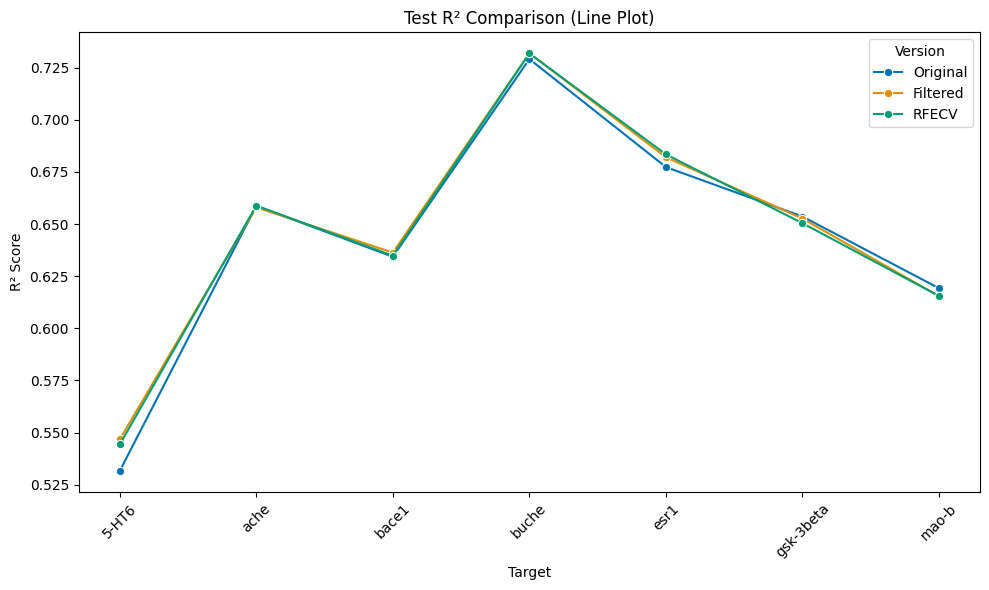

In [12]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=results_df, x="Target", y="Test R²", hue="Version", marker='o', palette=palette)
plt.title("Test R² Comparison (Line Plot)")
plt.ylabel("R² Score")
plt.xlabel("Target")
plt.xticks(rotation=45)
plt.tight_layout()

# Save plot
plt.savefig("/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/reduced_features_reu_2/test_r2_comparison_line_plot.png", dpi=300)
plt.show()


# **Plotting RF Model Performance Comparison**

/tmp/ipython-input-116602896.py:10: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(data=df, x="Target", y=metric_col, hue="Version", palette=palette)


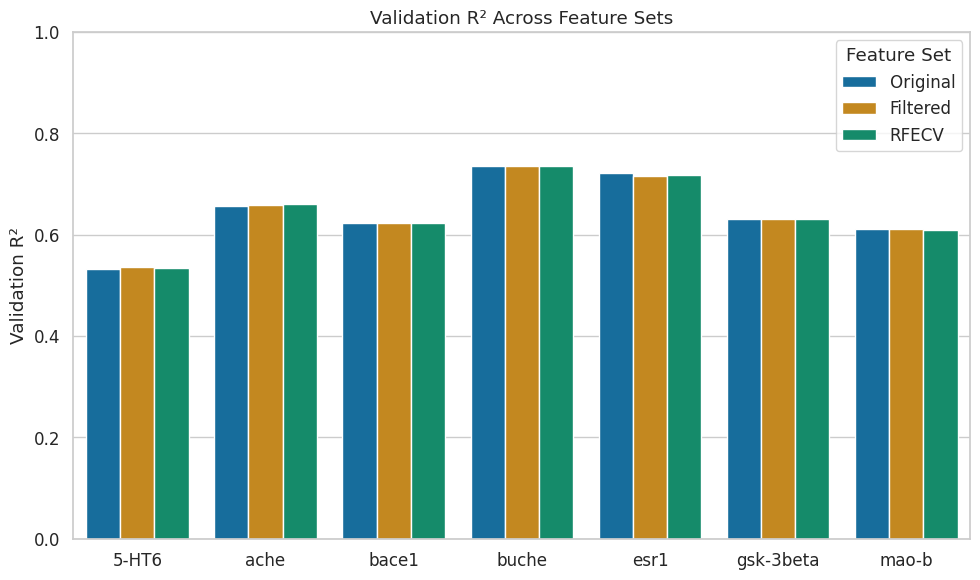

/tmp/ipython-input-116602896.py:10: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(data=df, x="Target", y=metric_col, hue="Version", palette=palette)


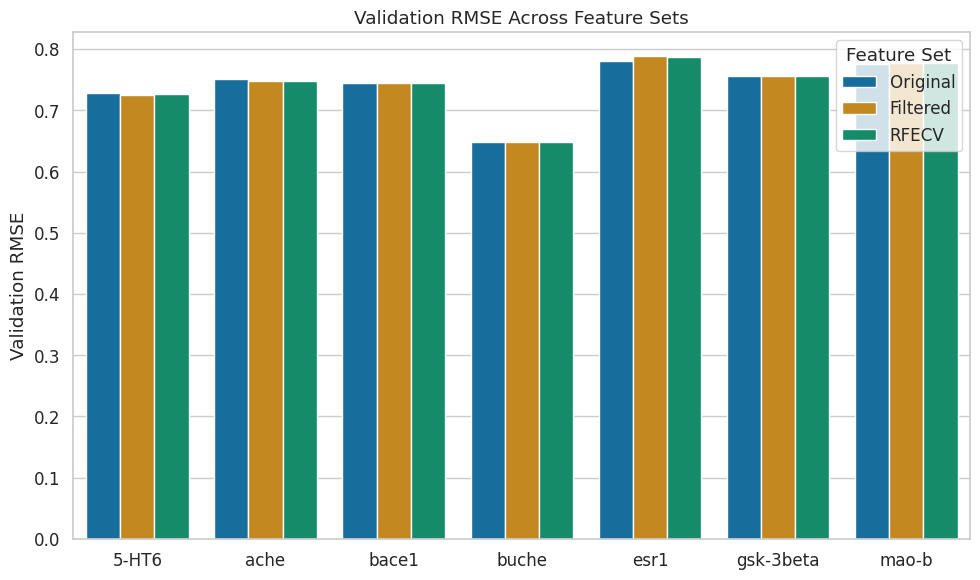

/tmp/ipython-input-116602896.py:10: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(data=df, x="Target", y=metric_col, hue="Version", palette=palette)


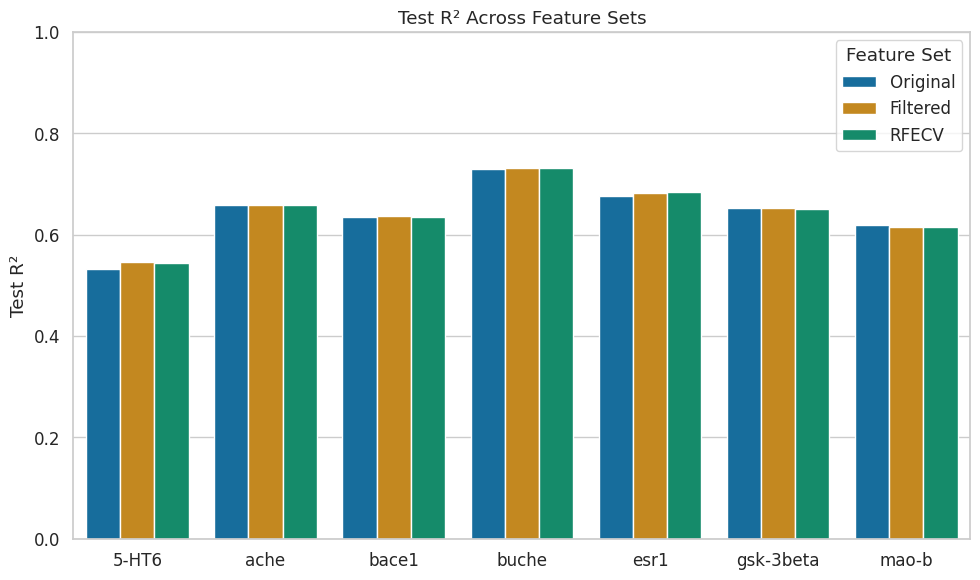

/tmp/ipython-input-116602896.py:10: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(data=df, x="Target", y=metric_col, hue="Version", palette=palette)


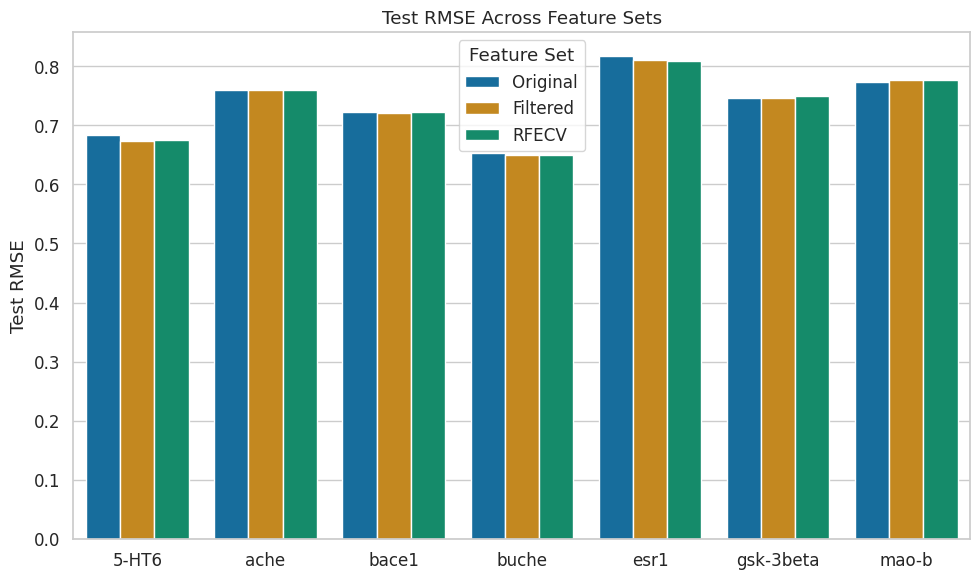

In [13]:
output_dir = "/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/reduced_features_reu_2/"

# === Set Plot Style ===
sns.set(style="whitegrid", font_scale=1.1)
palette = sns.color_palette("colorblind")

# === Define plotting function ===
def plot_metric(df, metric_col, title, ylabel, filename, ylim=None):
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x="Target", y=metric_col, hue="Version", palette=palette)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("")
    if ylim:
        plt.ylim(ylim)
    plt.legend(title="Feature Set")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, filename), dpi=300)
    plt.show()

# === Plot Validation and Test Metrics ===
plot_metric(
    results_df,
    metric_col="Val R²",
    title="Validation R² Across Feature Sets",
    ylabel="Validation R²",
    filename="val_r2_rf.png",
    ylim=(0, 1)
)

plot_metric(
    results_df,
    metric_col="Val RMSE",
    title="Validation RMSE Across Feature Sets",
    ylabel="Validation RMSE",
    filename="val_rmse_rf.png"
)

plot_metric(
    results_df,
    metric_col="Test R²",
    title="Test R² Across Feature Sets",
    ylabel="Test R²",
    filename="test_r2_rf.png",
    ylim=(0, 1)
)

plot_metric(
    results_df,
    metric_col="Test RMSE",
    title="Test RMSE Across Feature Sets",
    ylabel="Test RMSE",
    filename="test_rmse_rf.png"
)
